# Ploting and Calculating Transect Areas

<span style="color:red">This code was last tested on February 25, 2026, and is running without issues.</span>


<span style="color:red">Here we need the file: pts_transects_final.pkl, which was previously generated manually, selecting coordinates of transect areas along the channel </span>

**PURPOSE:** After Running the STEP1, 2 and 3 you can run this code to calculate the transect areas on the thalweg of the channel  

__________________________________________________________________________________________  

**Input files:**  

   
lc_debora.pkl  
2024_30m funcionando.xyz  
on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/input_dir/bathymetry_data/"  


pts_transects_final.pkl  
on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/input_dir/other_data/"  


**Output files:** 


Transects_on_the_map.png  
Transect_57areas.png  
longitudinal_variation_cross_sections.png  

on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/output_dir/processed_image/"  
__________________________________________________________________________________________

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import os
import matplotlib

from scipy.spatial.distance import cdist
from scipy.integrate import trapezoid

from pyproj import CRS
from pyproj import Transformer

from shapely import Polygon
from shapely import Point
from shapely.geometry import Polygon

from scipy.interpolate import griddata


import pickle

In [2]:
#open data with margins of the channel and bathymetry:

input_data1 = '../input_dir/bathymetry_data/'
input_data2 = '../input_dir/other_data/'
output_image = '../output_dir/processed_image/'

with open(input_data1 +'lc_debora.pkl', 'rb') as io:
        pts = pickle.load(io)

with open(input_data1 + '2024_30m funcionando.xyz') as io:
    lines = io.readlines()


In [3]:
# naming the points (margin): 

pts_margemleste = pts[0]
pts_margemoeste = pts[1]
pts_limitedelta = pts[2]
pts_ilhas = pts[3]


In [4]:
# naming the bathymetry (x,y,z):
xyz = []
for li in lines:
    liq = li.split()
    floats = [float(x) for x in liq]
    xyz.append(floats) 

xyz = np.array(xyz)
x = xyz[:,0]
y = xyz[:,1]
z = xyz[:,2]

In [5]:
# open the select coordenates of the transect from the bathymetry notebook: 

#path2 = "/Users/deboragadelha/Jupyter/barros_et_al_2026/input_dir/other_data/"
#path2 = "/Users/deboragadelha/Jupyter/campo_18julho2022_paper/processed_data/"

with open(input_data2 +'pts_transects_final.pkl', 'rb') as io:
        pts_transect = pickle.load(io)

<span style="color:red">Pay attention that before running the next cell you must DISABLED one line in the first round and ENABLED it for the following rounds</span>

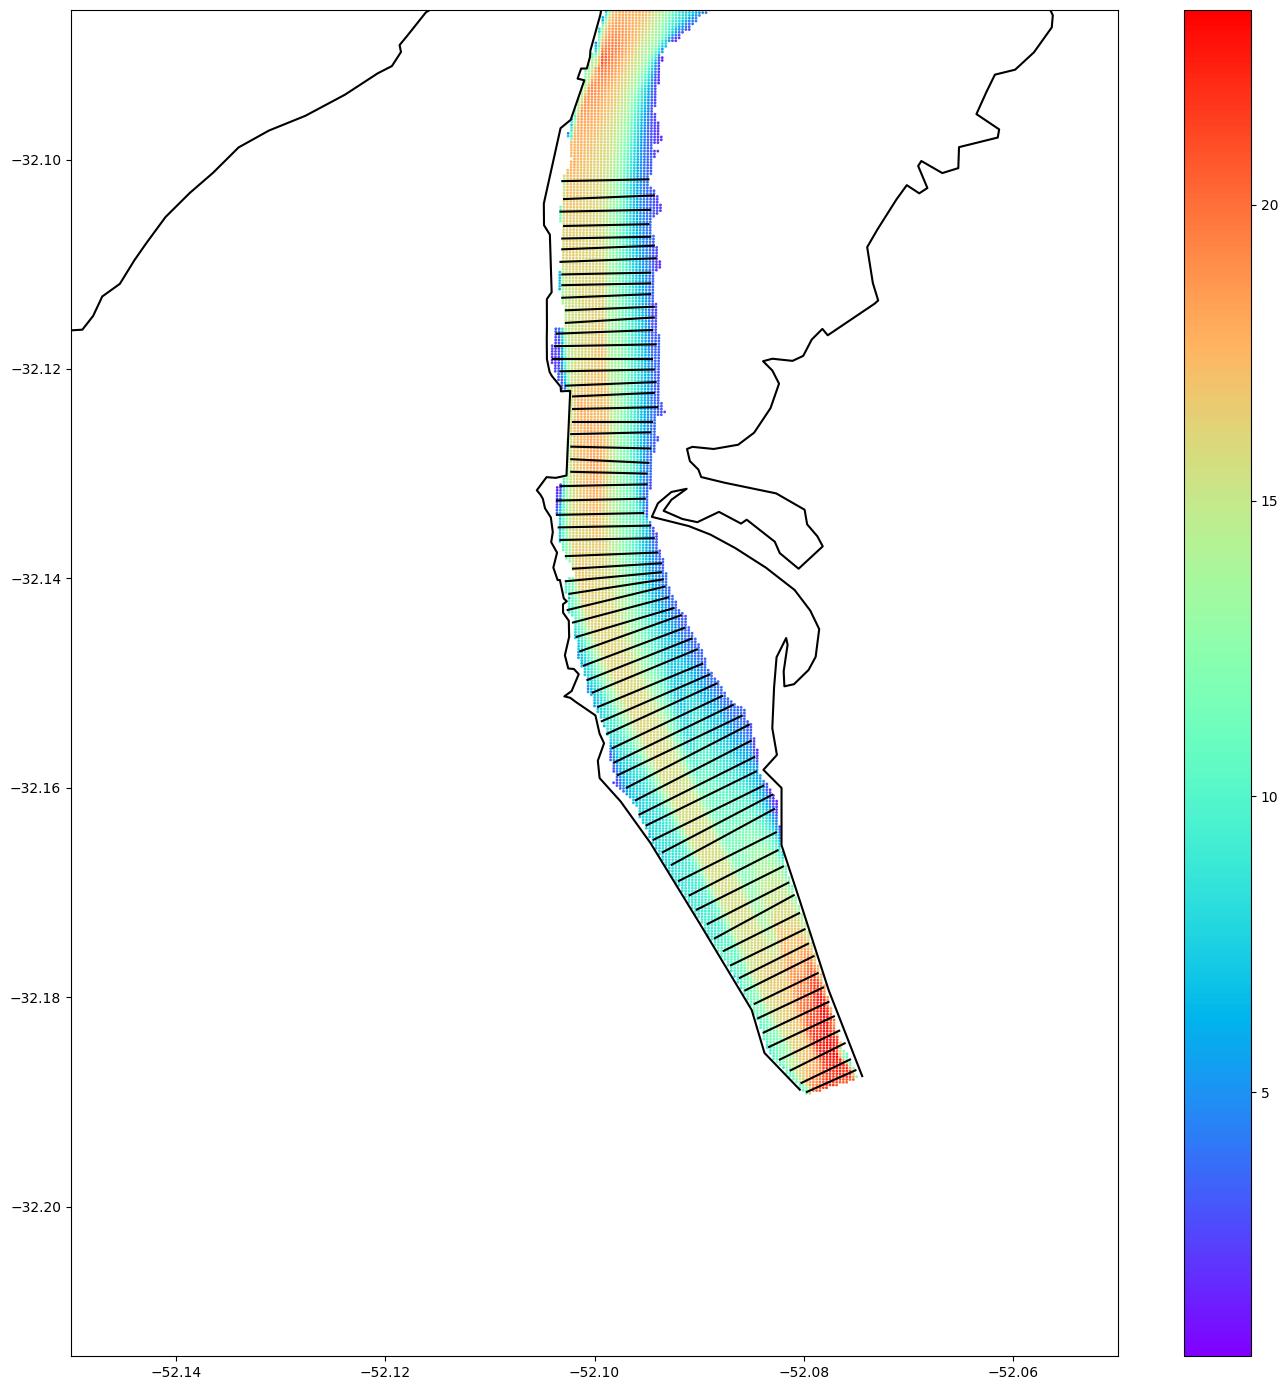

In [6]:
fig, ax = plt.subplots(figsize=(14,14))

ax.plot(pts_margemleste[:,0], pts_margemleste[:,1], 'k')
ax.plot(pts_margemoeste[:,0], pts_margemoeste[:,1], 'k')
ax.plot(pts_limitedelta[:,0], pts_limitedelta[:,1], 'k')
#ax.plot(-52.09895245938756, -32.11726638106521, 'ok') #primeiro cast
#ax.plot(-52.078365, -32.18846333, 'ok') #ultimo cast dentro de barra

for s in pts_ilhas:
    ax.plot(s[:,0], s[:,1], 'k')
ax.axis('equal')

cb=ax.scatter(x, y, c=z, s=1, cmap='rainbow')
ax.axis('equal')
ax.set_ylim(-32.2, -32.1)
ax.set_xlim(-52.15, -52.05)
plt.colorbar(cb)

for p in pts_transect:
    plt.plot(p[:,0], p[:,1], 'k') # DISABLED in the first round and ENABLED for the following rounds

#pts = plt.ginput(-1, -1)
plt.tight_layout()
plt.savefig(os.path.join(output_image,'Transects_on_the_map.png'), dpi=300)
plt.show()

After plotting the sections and marking the points where the first and last transects were performed inside the bay, we can see that the first 13 sections I traced are outside the field area, as shown in the figure below

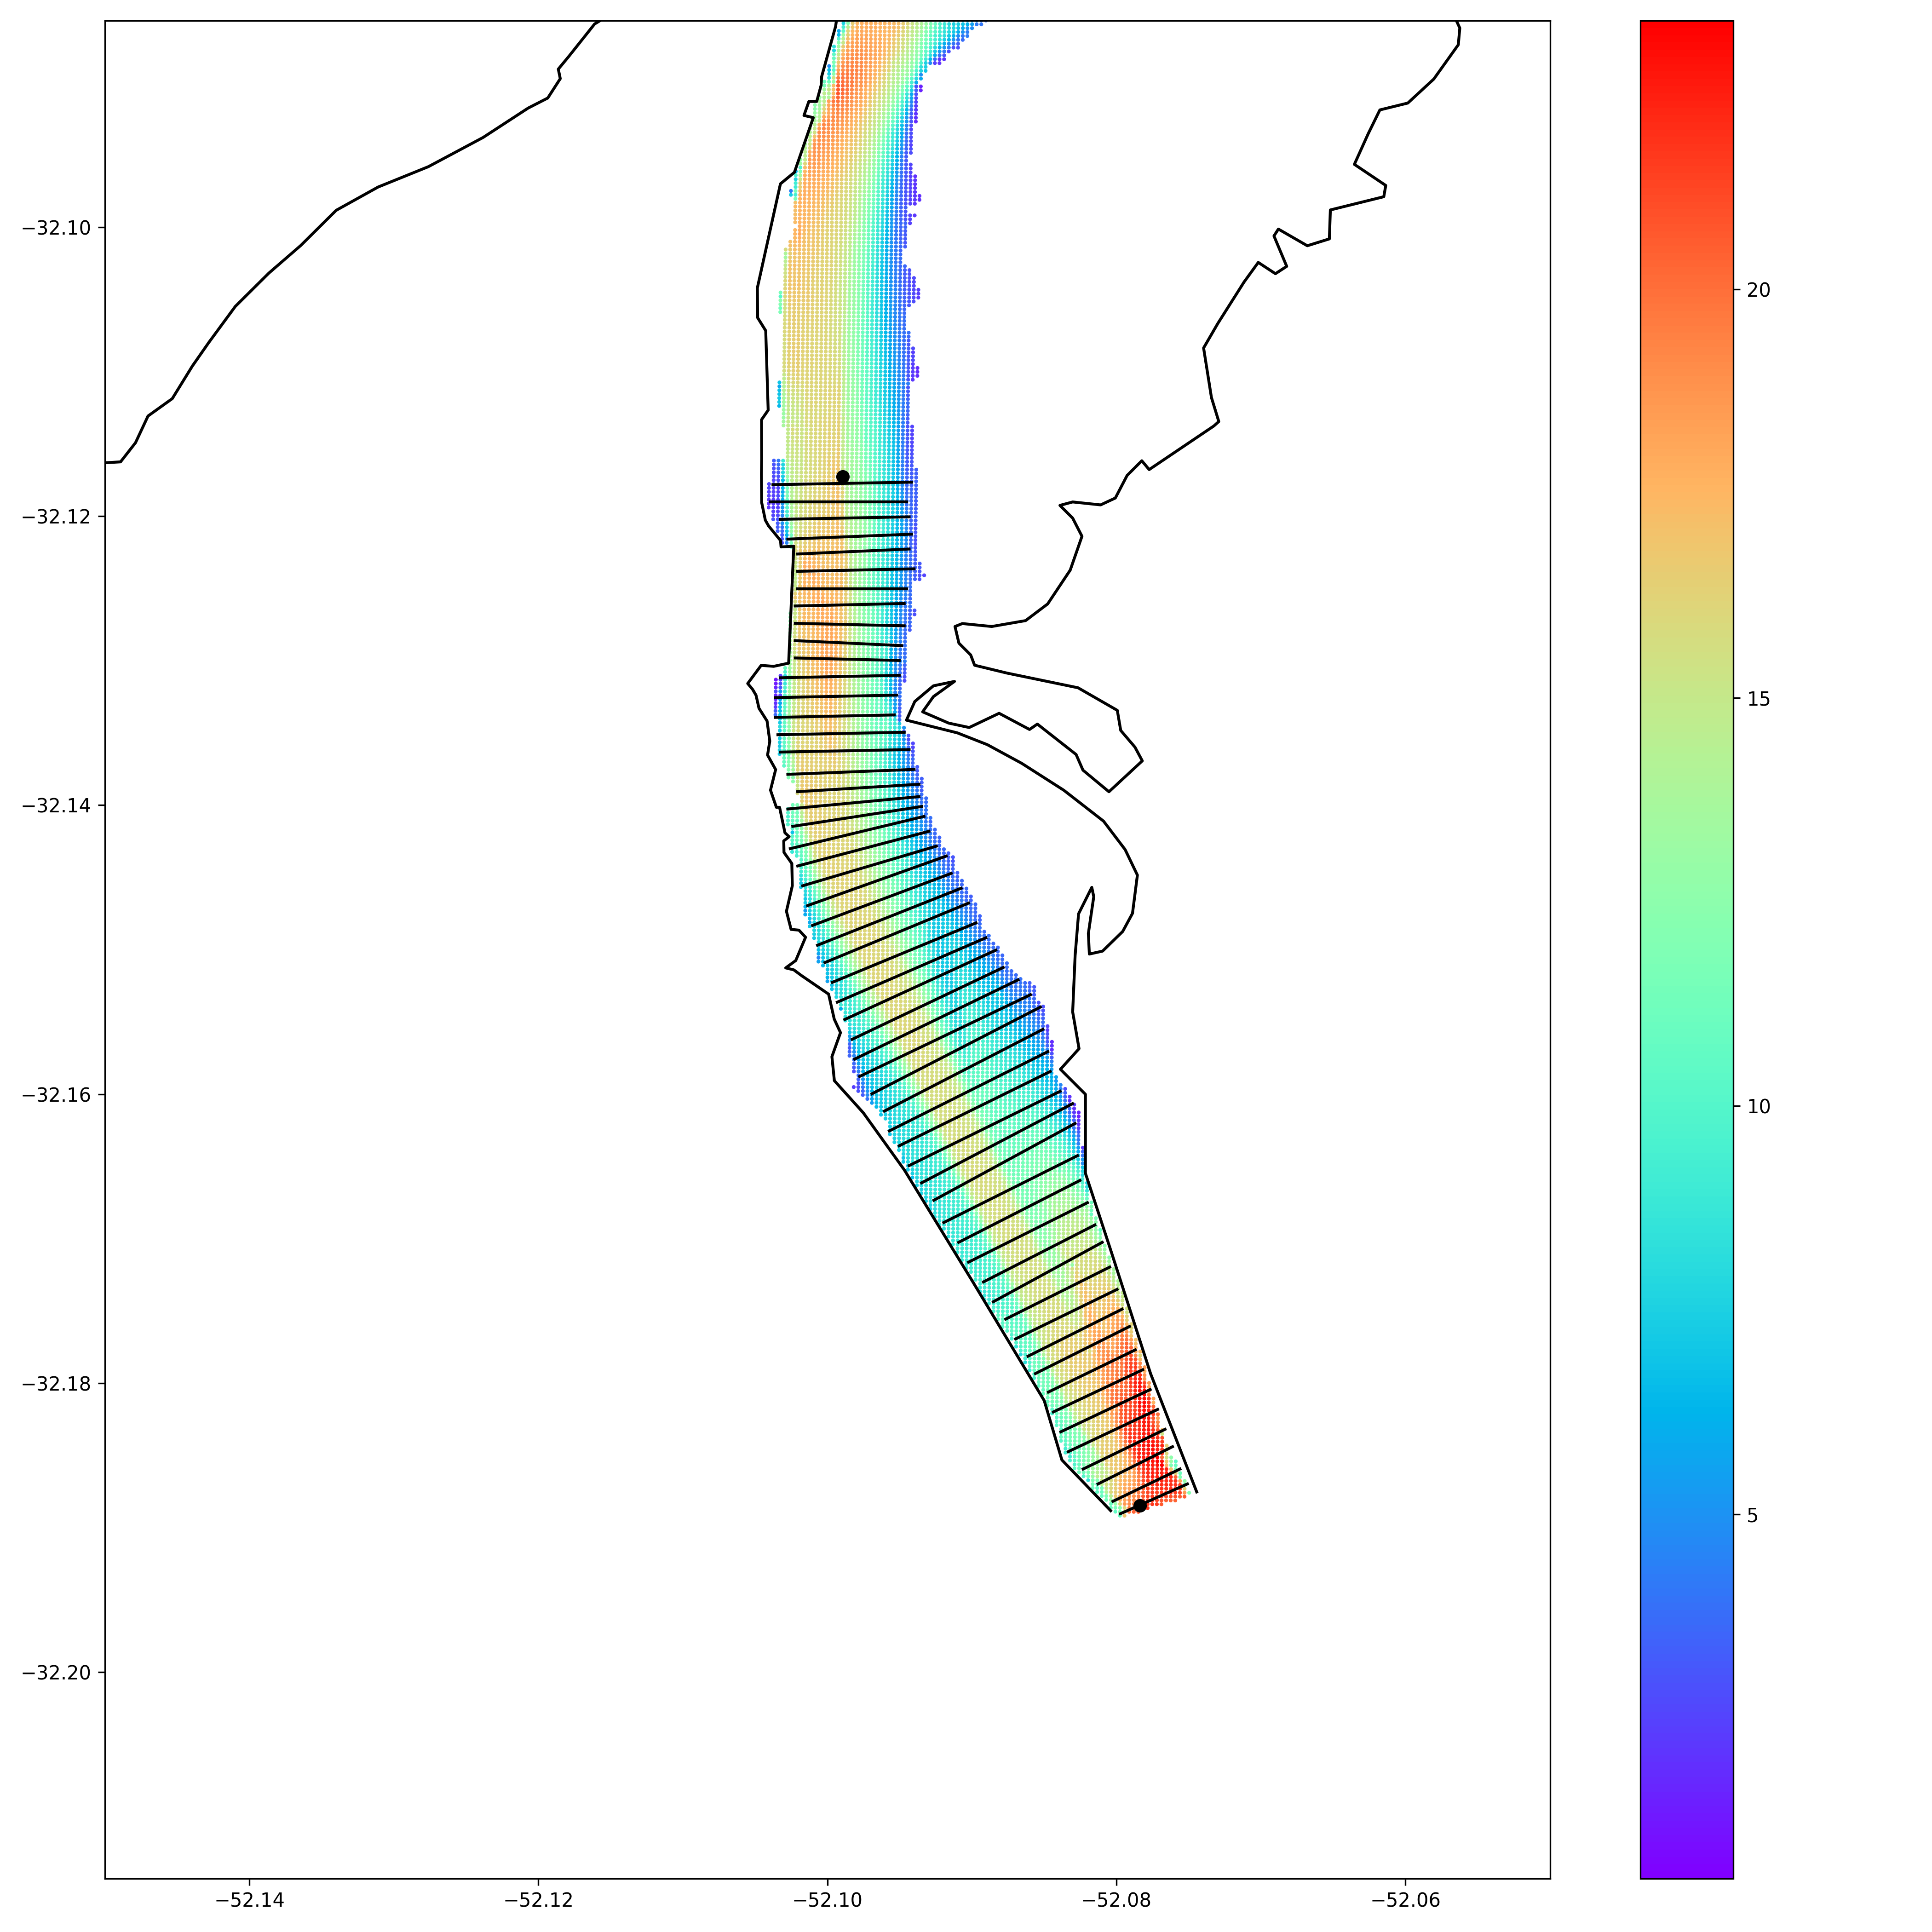


Then let's exclude the first 13 sections from the run and re-save the output to align the code

In [7]:
pts_transect_field = pts_transect[13:]
#areas_field = areas [13:]

In [8]:
print(len(pts_transect))          # original total 
print(len(pts_transect_field))    # total after removing the first 13 transects

70
57


In [15]:
def calculate_closed_area(p1, p2, x, y, z, width=50):
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    L = np.sqrt(dx**2 + dy**2)
    if L == 0:
        return np.nan, None, None, None
    ux, uy = dx / L, dy / L

    x_rel = x - p1[0]
    y_rel = y - p1[1]

    dist_along = x_rel * ux + y_rel * uy
    dist_perp = np.abs(x_rel * (-uy) + y_rel * ux)

    mask = (dist_perp < width) & (dist_along >= 0) & (dist_along <= L)
    if np.sum(mask) < 3:
        return np.nan, None, None, None

    dist_sel = dist_along[mask]
    depth_sel = z[mask]

    idx = np.argsort(dist_sel)
    dist_ord = dist_sel[idx]
    depth_ord = depth_sel[idx]

    # Create a polygon: surface + inverted bottom
    x_surface = np.array([0, L])
    y_surface = np.array([0, 0])

    x_bottom = dist_ord
    y_bottom = -depth_ord  # positive depth on the bottom 

    x_poly = np.concatenate([x_surface, x_bottom[::-1]])
    y_poly = np.concatenate([y_surface, y_bottom[::-1]])

    coords = list(zip(x_poly, y_poly))
    poly = Polygon(coords)
    area = poly.area

    return area, poly, dist_ord, depth_ord


def process_section_and_plot(pts_transect_field, x, y, z, width = 50):
    areas = []
    fig, axs = plt.subplots(10, 7, figsize=(22, 28), sharey=True)
    axs = axs.flatten()

    for i, (p1, p2) in enumerate(pts_transect_field):
        area, poly, dist, depth = calculate_closed_area(p1, p2, x, y, z, width = width)

        if np.isnan(area) or poly is None:
            axs[i].set_title(f'Section {i+1} - not valid')
            axs[i].axis('off')
            areas.append(np.nan)
            continue

        areas.append(area)

        # Plot closed polygon:
        x_poly, y_poly = poly.exterior.xy
        axs[i].fill(x_poly, y_poly, alpha=0.4, label='Área', color='skyblue')
        axs[i].plot(dist, -depth, 'k.', markersize=1.5, label='Bathymetry')
        axs[i].plot([0, dist.max()], [0, 0], 'r-', linewidth=0.8, label='Surface')
        #axs[i].set_title(f'Seção {i+1}\nÁrea = {area:.0f} m²', fontsize=9)
        axs[i].set_title(f'Seção {i+1}', fontsize=9)

        # Add area in the center of the diagram: 
        center_x = 0.5 * dist.max()
        center_y = -np.nanmax(depth) * 0.5  # vertical position on the depth 
        axs[i].text(center_x, center_y, f"{area:.0f} m²", fontsize=8, color='black',
            ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        axs[i].set_xlabel('Distance (m)')
        axs[i].set_ylabel('Depth (m)')
        axs[i].grid(True)

    for j in range(i+1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(output_image,'Transect_57areas.png'), dpi=300)

    #plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/Transect_57areas.png", dpi=300)
    plt.show()

    return areas


In [16]:
#Due to a distance error, we verified that the coordinates were in degrees. We will now correct them:

# Defining your system (ex: zone 22S, WGS84)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32722", always_xy=True)  # long, lat -> UTM 22S

# Convert bathymetry
x_utm, y_utm = transformer.transform(x, y)

# Convert transect points 
pts_transects_utm = [(transformer.transform(p1[0], p1[1]),
                      transformer.transform(p2[0], p2[1])) for p1, p2 in pts_transect_field]


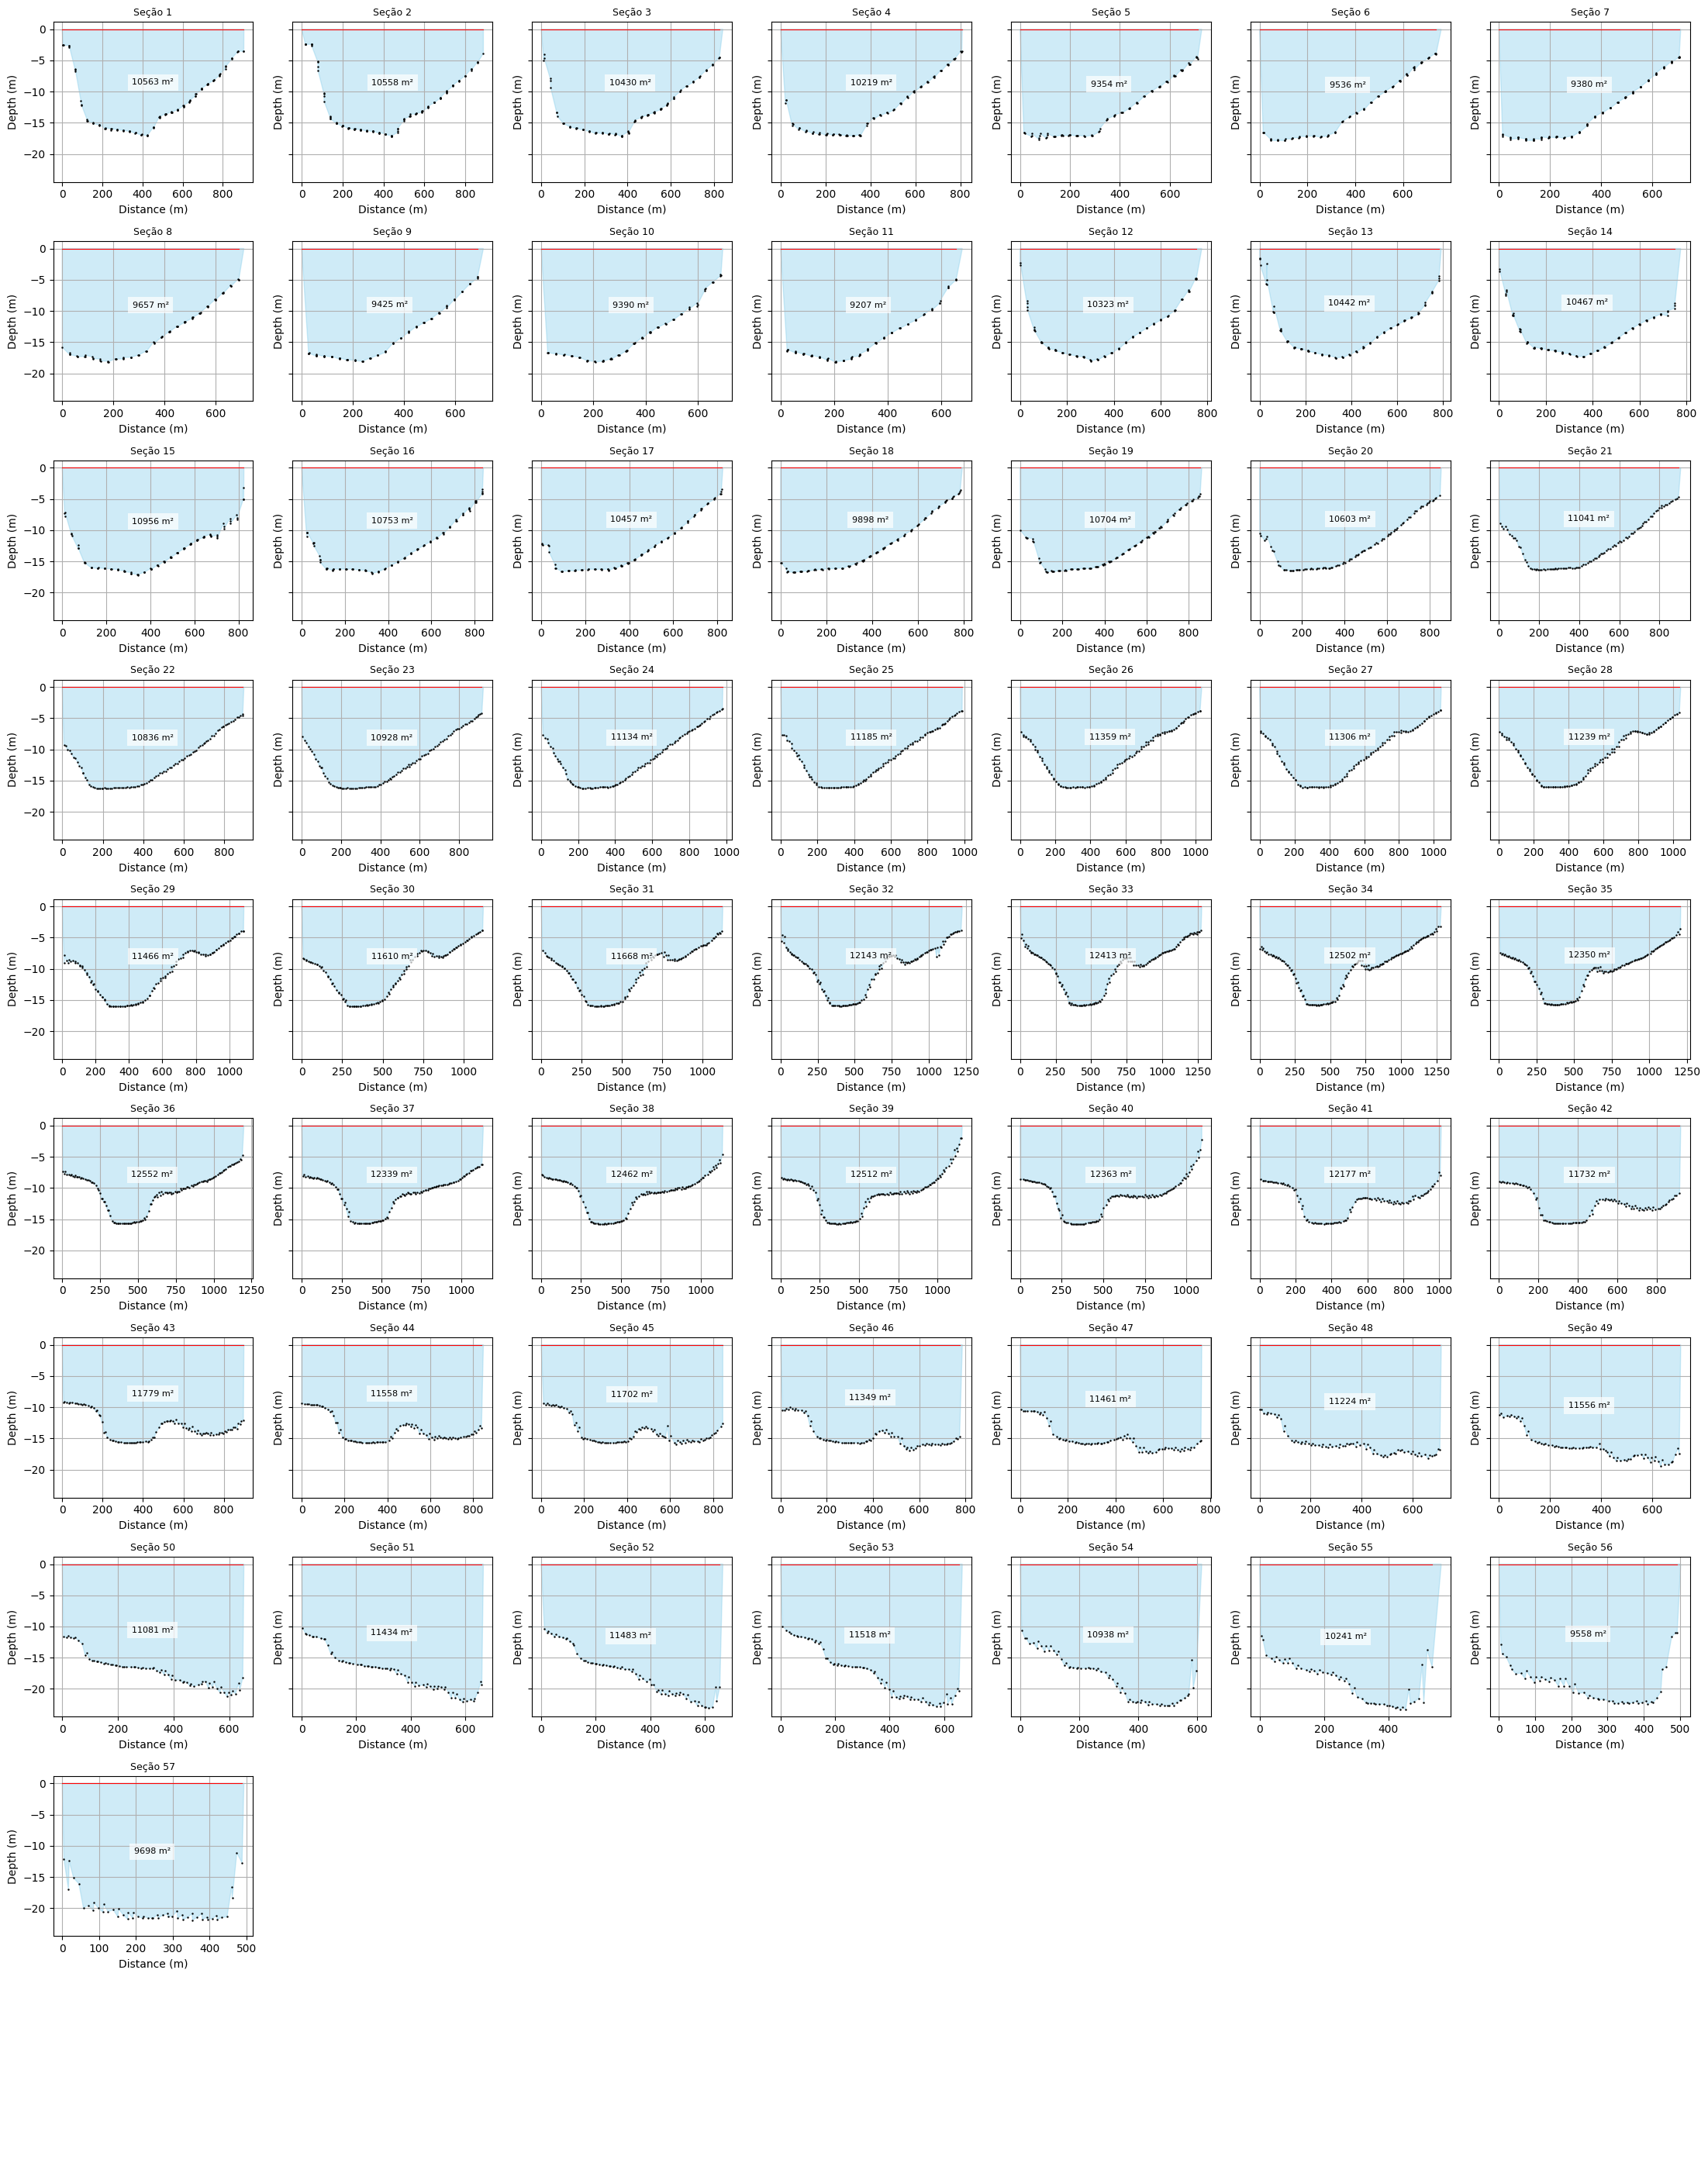

In [17]:
areas = process_section_and_plot(pts_transects_utm, x_utm, y_utm, z, width=50)

## 

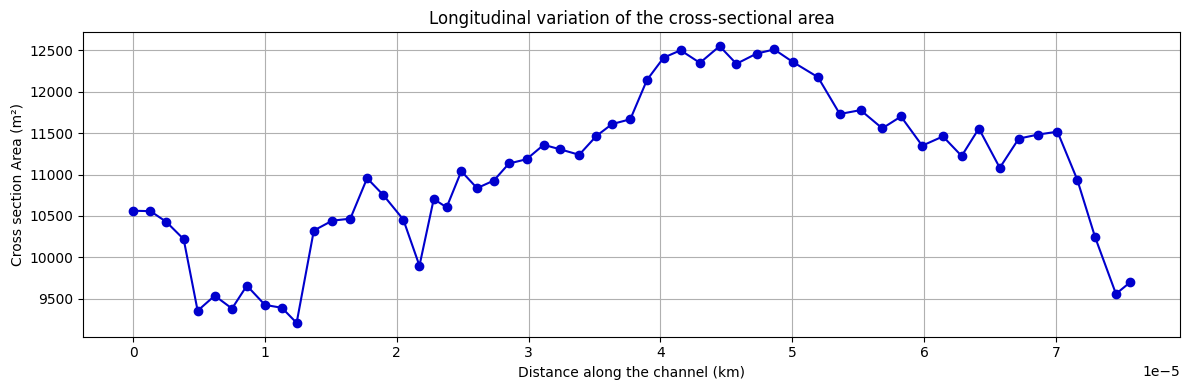

In [18]:
# === 1. Calculate mean point in each section ===
mean_point = np.array([
                        [(p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2]
                        for (p1, p2) in pts_transect_field
                        ])

# === 2. Calculate acumulated distance along channel (in km) ===
distance = np.cumsum(
                        [0] + [np.hypot(mean_point[i,0] - mean_point[i-1,0],
                        mean_point[i,1] - mean_point[i-1,1])
                        for i in range(1, len(mean_point))]
                        )
distance_km = distance / 1000  # convert to km

# === 3. Convert areas to array to use the mask easier ===
areas_np = np.array(areas)

# === 4. Plot as longitudinal section  ===
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(distance_km[~np.isnan(areas_np)], areas_np[~np.isnan(areas_np)], '-o', color='mediumblue')
ax.set_xlabel('Distance along the channel (km)')
ax.set_ylabel('Cross section Area (m²)')
ax.set_title('Longitudinal variation of the cross-sectional area')
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_image,'longitudinal_variation_cross_sections.png'), dpi=300)
plt.show()


<span style="color:red">This code was last tested on February 24, 2026, and is running without issues.</span>


## END OF CODE